In [33]:
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np

In [34]:
df = pd.read_csv('heart_disease.csv')
df


,Age,Gender,Blood Pressure,Cholesterol Level,Exercise Habits,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,...,High LDL Cholesterol,Alcohol Consumption,Stress Level,Sleep Hours,Sugar Consumption,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,High,Yes,Yes,No,24.991591,Yes,...,No,High,Medium,7.633228,Medium,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,High,No,Yes,Yes,25.221799,No,...,No,Medium,High,8.744034,Medium,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,Low,No,No,No,29.855447,No,...,Yes,Low,Low,4.440440,Low,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,High,Yes,Yes,No,24.130477,Yes,...,Yes,Low,High,5.249405,High,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Low,Yes,Yes,Yes,20.486289,Yes,...,No,Low,High,7.030971,High,263.0,154.0,10.381259,8.153887,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25.0,Female,136.0,243.0,Medium,Yes,No,No,18.788791,Yes,...,Yes,Medium,High,6.834954,Medium,343.0,133.0,3.588814,19.132004,Yes
9996,38.0,Male,172.0,154.0,Medium,No,No,No,31.856801,Yes,...,Yes,NaN,High,8.247784,Low,377.0,83.0,2.658267,9.715709,Yes
9997,73.0,Male,152.0,201.0,High,Yes,No,Yes,26.899911,No,...,Yes,NaN,Low,4.436762,Low,248.0,88.0,4.408867,9.492429,Yes
9998,23.0,Male,142.0,299.0,Low,Yes,No,Yes,34.964026,Yes,...,Yes,Medium,High,8.526329,Medium,113.0,153.0,7.215634,11.873486,Yes


In [35]:
df.columns

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='str')

In [36]:
df.isnull().sum()

Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64

In [37]:
df = df.drop([
    'Exercise Habits',
    'Alcohol Consumption',
    'Stress Level',
    'Sleep Hours',
    'Sugar Consumption'
], axis=1)

In [38]:
df

,Age,Gender,Blood Pressure,Cholesterol Level,Smoking,Family Heart Disease,Diabetes,BMI,High Blood Pressure,Low HDL Cholesterol,High LDL Cholesterol,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Heart Disease Status
0,56.0,Male,153.0,155.0,Yes,Yes,No,24.991591,Yes,Yes,No,342.0,NaN,12.969246,12.387250,No
1,69.0,Female,146.0,286.0,No,Yes,Yes,25.221799,No,Yes,No,133.0,157.0,9.355389,19.298875,No
2,46.0,Male,126.0,216.0,No,No,No,29.855447,No,Yes,Yes,393.0,92.0,12.709873,11.230926,No
3,32.0,Female,122.0,293.0,Yes,Yes,No,24.130477,Yes,No,Yes,293.0,94.0,12.509046,5.961958,No
4,60.0,Male,166.0,242.0,Yes,Yes,Yes,20.486289,Yes,No,No,263.0,154.0,10.381259,8.153887,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25.0,Female,136.0,243.0,Yes,No,No,18.788791,Yes,No,Yes,343.0,133.0,3.588814,19.132004,Yes
9996,38.0,Male,172.0,154.0,No,No,No,31.856801,Yes,No,Yes,377.0,83.0,2.658267,9.715709,Yes
9997,73.0,Male,152.0,201.0,Yes,No,Yes,26.899911,No,Yes,Yes,248.0,88.0,4.408867,9.492429,Yes
9998,23.0,Male,142.0,299.0,Yes,No,Yes,34.964026,Yes,No,Yes,113.0,153.0,7.215634,11.873486,Yes


In [39]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Smoking               9975 non-null   str    
 5   Family Heart Disease  9979 non-null   str    
 6   Diabetes              9970 non-null   str    
 7   BMI                   9978 non-null   float64
 8   High Blood Pressure   9974 non-null   str    
 9   Low HDL Cholesterol   9975 non-null   str    
 10  High LDL Cholesterol  9974 non-null   str    
 11  Triglyceride Level    9974 non-null   float64
 12  Fasting Blood Sugar   9978 non-null   float64
 13  CRP Level             9974 non-null   float64
 14  Homocysteine Level    9980 non-null   float64
 15  Heart Disease Status  10000 non

In [40]:
df.isnull().sum()

Age                     29
Gender                  19
Blood Pressure          19
Cholesterol Level       30
Smoking                 25
Family Heart Disease    21
Diabetes                30
BMI                     22
High Blood Pressure     26
Low HDL Cholesterol     25
High LDL Cholesterol    26
Triglyceride Level      26
Fasting Blood Sugar     22
CRP Level               26
Homocysteine Level      20
Heart Disease Status     0
dtype: int64

In [41]:
# Get all numeric columns
# select_dtypes() is used to select columns based on data types
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns #choose integer and float format
print(numeric_columns)

# Get all categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns #object is text format
print(categorical_columns)


# Fill NaN values in numeric columns using median
for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median()) 

# Fill NaN values in categorical columns using mode
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

Index(['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI',
       'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level',
       'Homocysteine Level'],
      dtype='str')
Index(['Gender', 'Smoking', 'Family Heart Disease', 'Diabetes',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Heart Disease Status'],
      dtype='str')


C:\Users\lance\AppData\Local\Temp\ipykernel_55064\1300746543.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object']).columns #object is text format


In [42]:
df.isnull().sum()

Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64

In [43]:
## Convert categorical variables into numeric variables(True and False)
df = pd.get_dummies(df, drop_first=True)

# Convert boolean columns into integers
bool_columns = df.select_dtypes(include=['bool']).columns

for col in bool_columns:
    df[col] = df[col].astype(int) 
df

,Age,Blood Pressure,Cholesterol Level,BMI,Triglyceride Level,Fasting Blood Sugar,CRP Level,Homocysteine Level,Gender_Male,Smoking_Yes,Family Heart Disease_Yes,Diabetes_Yes,High Blood Pressure_Yes,Low HDL Cholesterol_Yes,High LDL Cholesterol_Yes,Heart Disease Status_Yes
0,56.0,153.0,155.0,24.991591,342.0,120.0,12.969246,12.387250,1,1,1,0,1,1,0,0
1,69.0,146.0,286.0,25.221799,133.0,157.0,9.355389,19.298875,0,0,1,1,0,1,0,0
2,46.0,126.0,216.0,29.855447,393.0,92.0,12.709873,11.230926,1,0,0,0,0,1,1,0
3,32.0,122.0,293.0,24.130477,293.0,94.0,12.509046,5.961958,0,1,1,0,1,0,1,0
4,60.0,166.0,242.0,20.486289,263.0,154.0,10.381259,8.153887,1,1,1,1,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,25.0,136.0,243.0,18.788791,343.0,133.0,3.588814,19.132004,0,1,0,0,1,0,1,1
9996,38.0,172.0,154.0,31.856801,377.0,83.0,2.658267,9.715709,1,0,0,0,1,0,1,1
9997,73.0,152.0,201.0,26.899911,248.0,88.0,4.408867,9.492429,1,1,0,1,0,1,1,1
9998,23.0,142.0,299.0,34.964026,113.0,153.0,7.215634,11.873486,1,1,0,1,1,0,1,1


In [44]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target variable
X = df.drop('Heart Disease Status_Yes', axis=1)
y = df['Heart Disease Status_Yes']

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create StandardScaler object
scaler = StandardScaler()

# Fit and transform training data
X_train = scaler.fit_transform(X_train)

# Transform testing data
X_test = scaler.transform(X_test)

In [45]:
print(X_train.shape,
      X_test.shape,
      y_train.shape,
      y_test.shape)


(8000, 15) (2000, 15) (8000,) (2000,)


       DECISION TREE BASELINE TEST REPORT
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.99      0.89      1600
           1       0.22      0.01      0.02       400

    accuracy                           0.80      2000
   macro avg       0.51      0.50      0.45      2000
weighted avg       0.68      0.80      0.71      2000



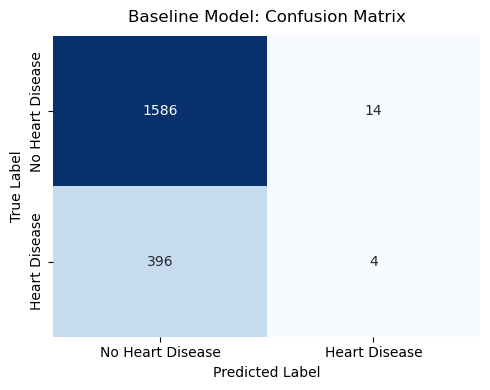

In [46]:
# Decision Tree Model


#Baseline Decision Tree Model

from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Initialize the tree model standalone
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# 2. Fit using preprocessed training array
dt_model.fit(X_train, y_train)

# 3. Predict on the held-out test set
y_test_pred = dt_model.predict(X_test)

# --- Performance Evaluation Text Outputs ---
print("=" * 60)
print("       DECISION TREE BASELINE TEST REPORT")
print("=" * 60)
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

# --- Plot Confusion Matrix Heatmap ---
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['No Heart Disease', 'Heart Disease'], 
    yticklabels=['No Heart Disease', 'Heart Disease'],
    cbar=False
)
plt.title('Baseline Model: Confusion Matrix', fontsize=12, pad=10)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


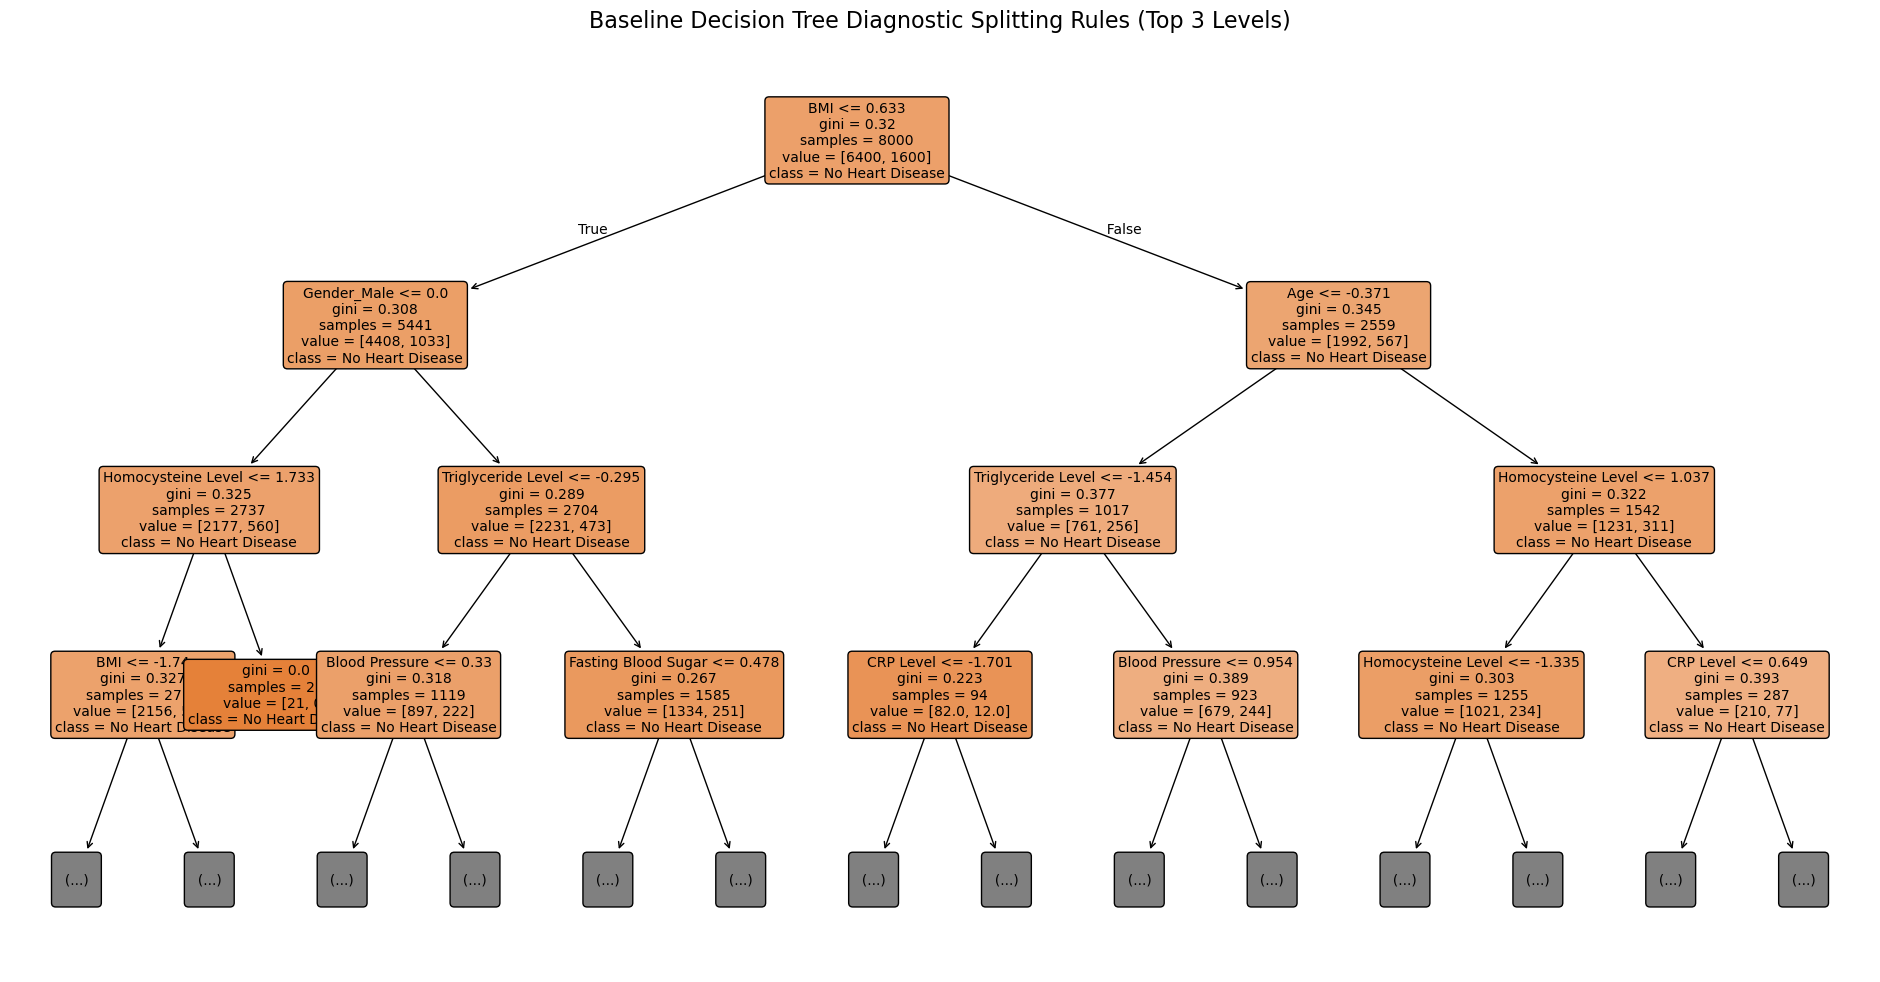

OPTIMAL HYPERPARAMETERS FOR DECISION TREE:
{'criterion': 'gini', 'max_depth': 7}
       DECISION TREE TUNED TEST REPORT
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.60      0.68      1600
           1       0.20      0.40      0.26       400

    accuracy                           0.56      2000
   macro avg       0.50      0.50      0.47      2000
weighted avg       0.68      0.56      0.60      2000



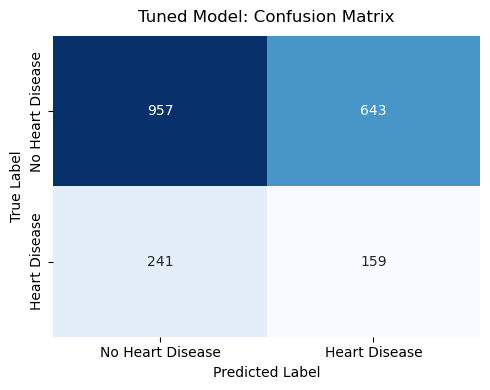

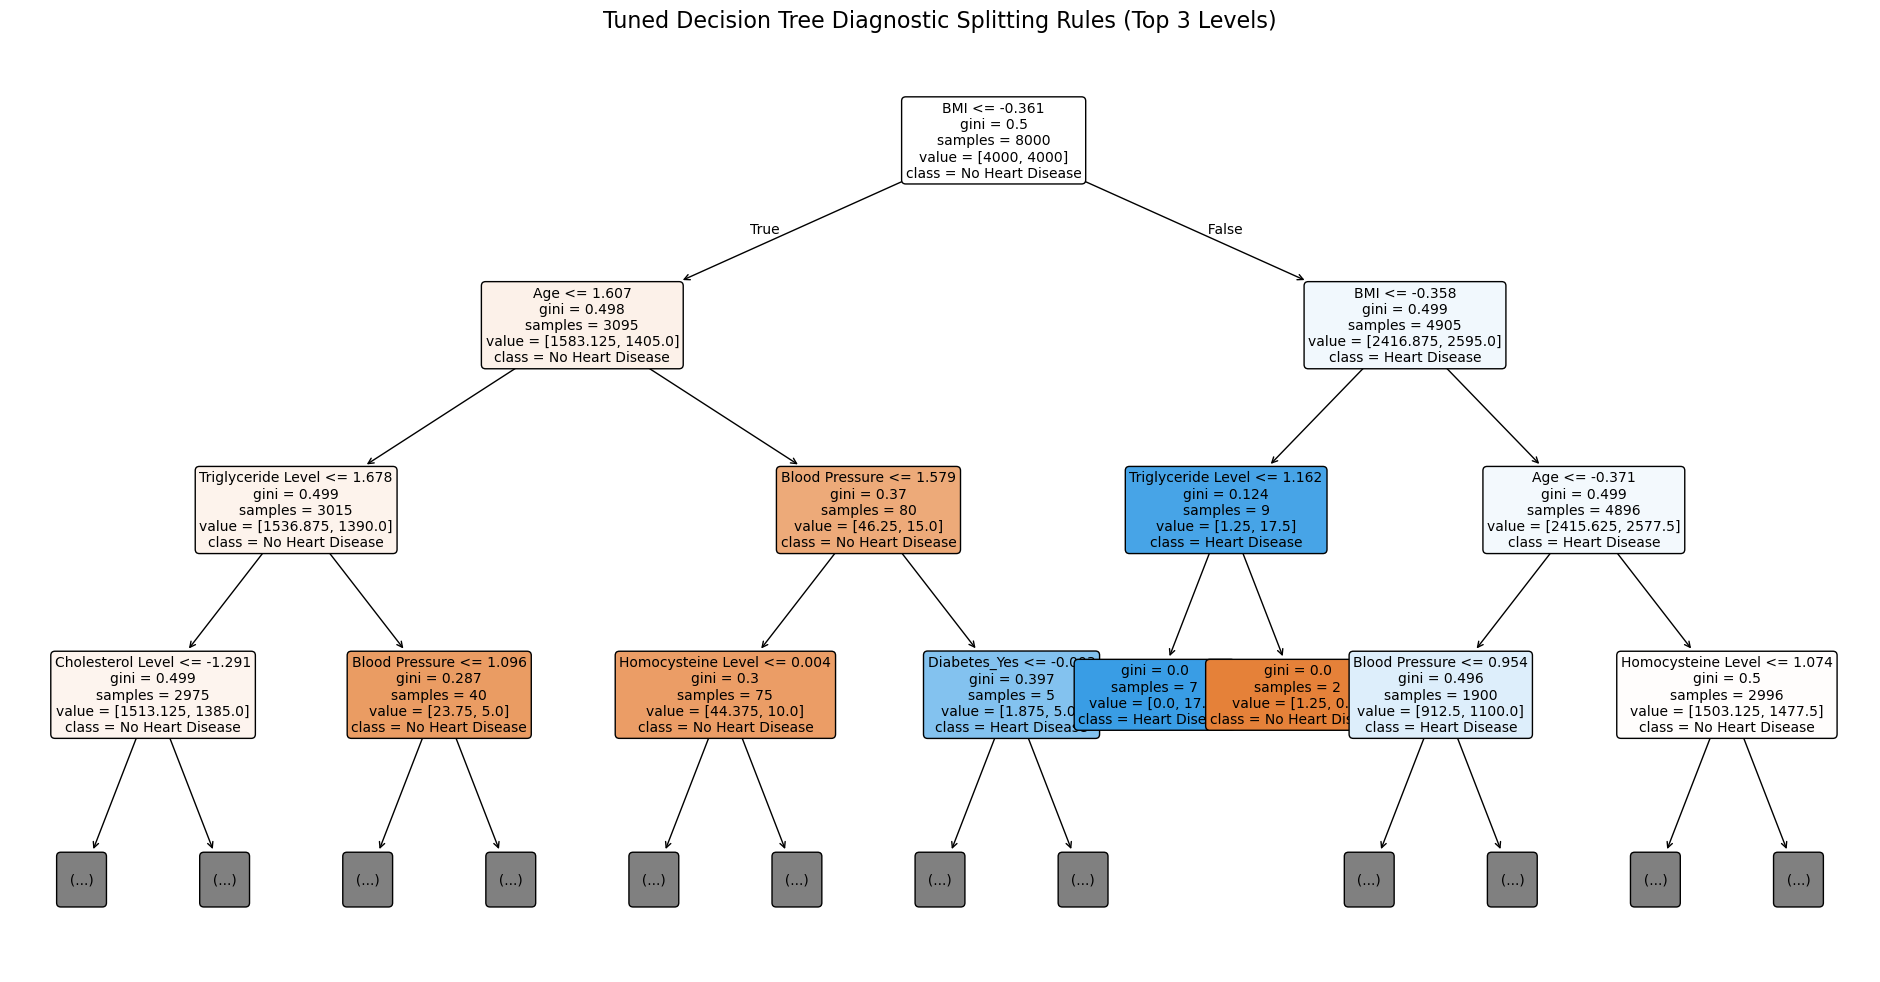

In [47]:

# --- Plot Labeled Decision Tree Diagram ---
# Bring in column feature names
feature_names = X.columns.tolist()

# Hardcode the class display text to completely bypass the internal 'clear' attribute bug
display_classes = ['No Heart Disease', 'Heart Disease']

# Create a dedicated, widescreen figure size so the text boxes have room to expand
plt.figure(figsize=(24, 12))

plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=display_classes,
    filled=True,          # Colors the nodes cleanly by majority class purity
    rounded=True,         # Gives the node boxes rounded edges
    fontsize=10,          # Keeps the split text legible
    max_depth=3           # Renders the top 3 tiers only
)

plt.title('Baseline Decision Tree Diagnostic Splitting Rules (Top 3 Levels)', fontsize=16, pad=15)
plt.show()

# GridSearchCV for Decision Tree

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize base tree
base_dt = DecisionTreeClassifier(random_state=42,class_weight='balanced')

# 2. Define grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'criterion': ['gini', 'entropy']
}

# 3. Set up GridSearch directly on the raw training split
# GridSearchCV will automatically create temporary internal validation folds
grid_search = GridSearchCV(
    estimator=base_dt,
    param_grid=param_grid,
    scoring='recall',  # Discussed this for our medical diagnosis context
    cv=5,
    n_jobs=-1
)

# 4. Fit directly on X_train DataFrame
grid_search.fit(X_train, y_train)

# ==========================================================
# 5. EVALUATION: Predict on the locked Test Set
# ==========================================================
tuned_model = grid_search.best_estimator_
y_test_pred = tuned_model.predict(X_test)

# --- Performance Evaluation Text Outputs ---
print("OPTIMAL HYPERPARAMETERS FOR DECISION TREE:")
print(grid_search.best_params_)
print("=" * 60)
print("       DECISION TREE TUNED TEST REPORT")
print("=" * 60)
print("Classification Report:")
print(classification_report(y_test, y_test_pred))

# --- Plot Confusion Matrix Heatmap ---
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['No Heart Disease', 'Heart Disease'], 
    yticklabels=['No Heart Disease', 'Heart Disease'],
    cbar=False
)
plt.title('Tuned Model: Confusion Matrix', fontsize=12, pad=10)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- Plot Labeled Decision Tree Diagram ---
# Bring in column feature names
feature_names = X.columns.tolist()

display_classes = ['No Heart Disease', 'Heart Disease']

plt.figure(figsize=(24, 12))

plot_tree(
    tuned_model,
    feature_names=feature_names,
    class_names=display_classes,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.title('Tuned Decision Tree Diagnostic Splitting Rules (Top 3 Levels)', fontsize=16, pad=15)
plt.show()


After removing selected features
Decision Tree Removed Features: 'Smoking_Yes', 'Diabetes_Yes'
              precision    recall  f1-score   support

           0       0.80      0.61      0.69      1613
           1       0.19      0.37      0.25       387

    accuracy                           0.57      2000
   macro avg       0.50      0.49      0.47      2000
weighted avg       0.68      0.57      0.61      2000



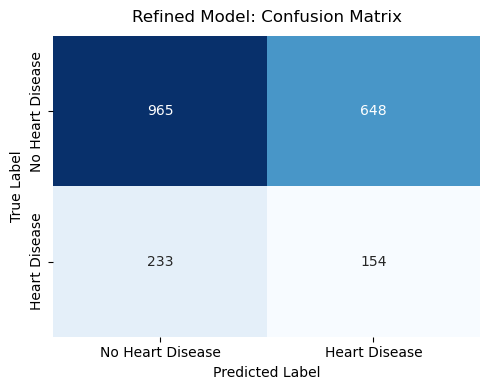

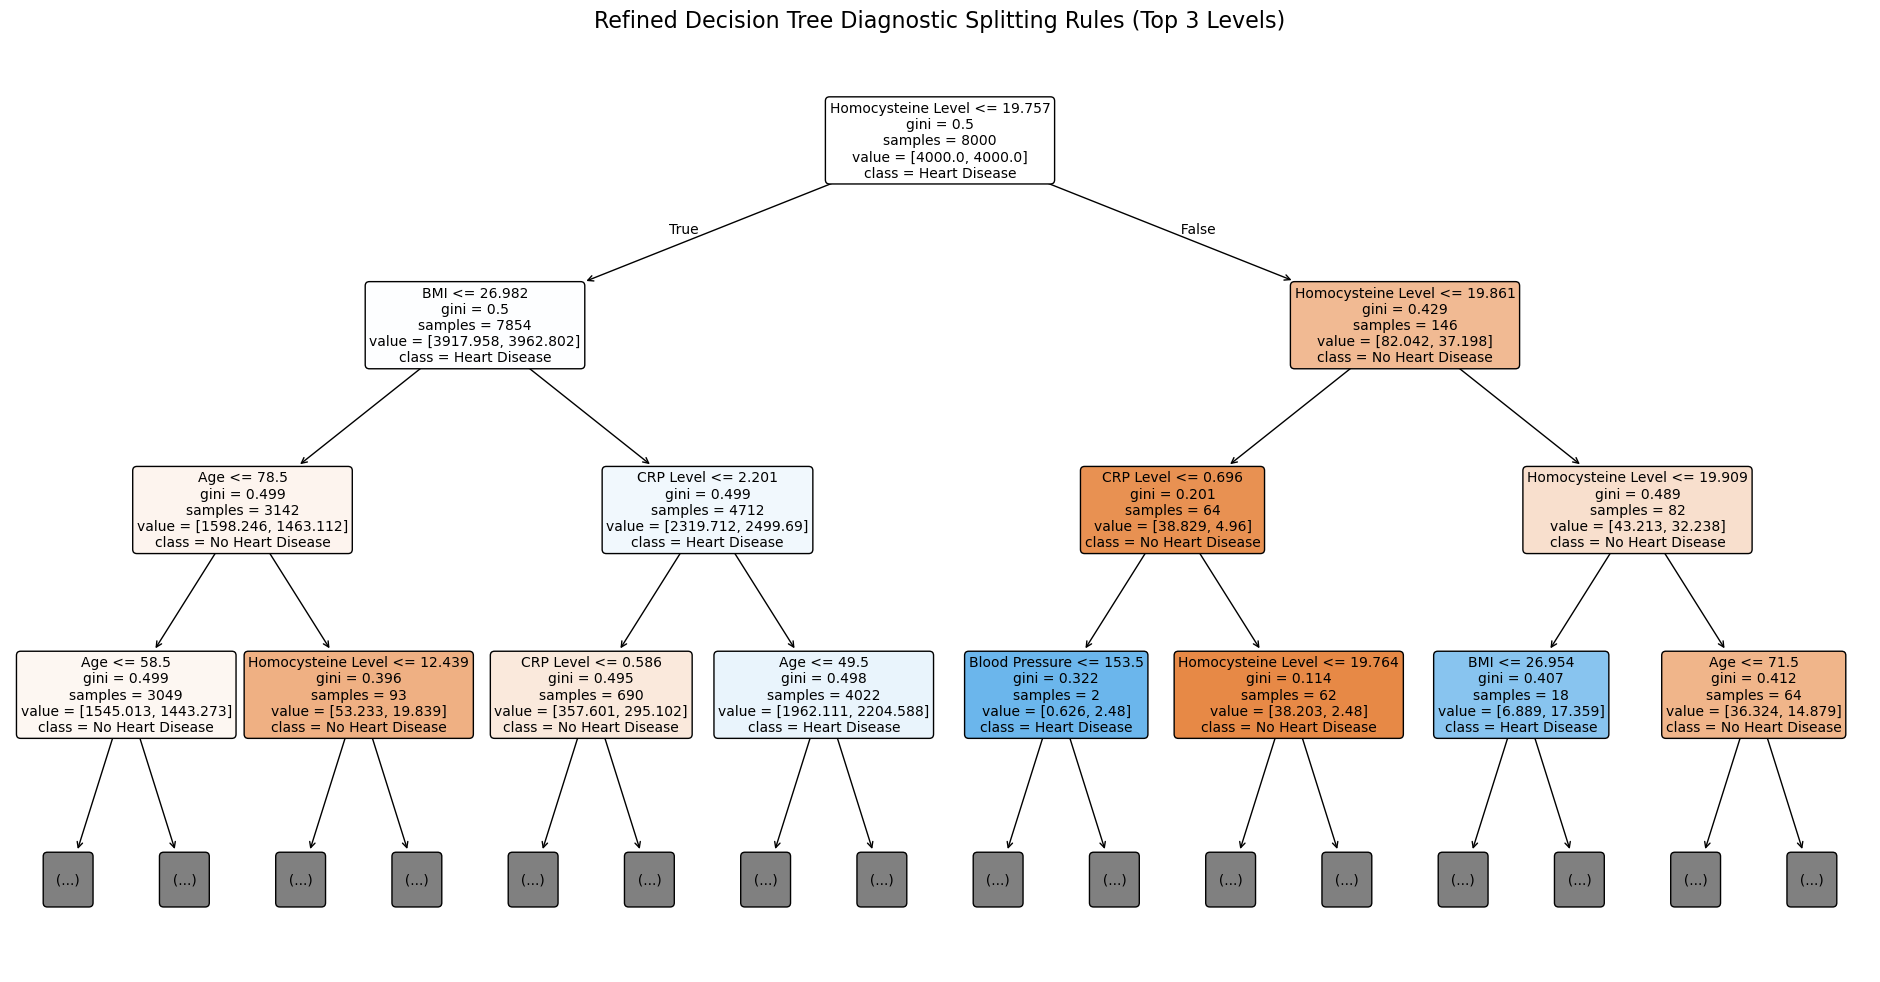

In [48]:
## Feature Removal Analysis for Decision Tree
# Store all feature names
features = X.columns

# Create empty list to store results
results = []

# Loop through each feature
for feature in features:

    # Remove one feature at a time
    X_reduced = X.drop(feature, axis=1)

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X_reduced,
        y,
        test_size=0.2,
        random_state=42
    )

    # Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train model
    tuned_model.fit(X_train, y_train)

    # Prediction
    y_pred = tuned_model.predict(X_test)

    # Get classification report as dictionary
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    # Store results
    results.append({
        'Decision Tree Removed Feature': feature,
        'Accuracy': report['accuracy'],
        'Precision (Class 1)': report['1']['precision'],
        'Recall (Class 1)': report['1']['recall'],
        'F1-Score (Class 1)': report['1']['f1-score']
    })

# Create dataframe
results_df = pd.DataFrame(results)

# Sort by recall from lowest to highest
results_df = results_df.sort_values(by='Recall (Class 1)', ascending=True)

# Display table
results_df

X = df.drop('Heart Disease Status_Yes', axis=1)

y = df['Heart Disease Status_Yes']

X_reduced = X.drop([
    'Smoking_Yes',
    'Diabetes_Yes'
], axis=1)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)
# Train model
tuned_model.fit(X_train, y_train)

# Predict
y_pred = tuned_model.predict(X_test)

# Show results
print("After removing selected features")
print("Decision Tree Removed Features: 'Smoking_Yes', 'Diabetes_Yes'")
print(classification_report(y_test, y_pred))

# --- Plot Confusion Matrix Heatmap ---
plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['No Heart Disease', 'Heart Disease'], 
    yticklabels=['No Heart Disease', 'Heart Disease'],
    cbar=False
)
plt.title('Refined Model: Confusion Matrix', fontsize=12, pad=10)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# --- Plot Labeled Decision Tree Diagram ---
# Bring in column feature names
feature_names = X.columns.tolist()

display_classes = ['No Heart Disease', 'Heart Disease']

plt.figure(figsize=(24, 12))

plot_tree(
    tuned_model,
    feature_names=feature_names,
    class_names=display_classes,
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.title('Refined Decision Tree Diagnostic Splitting Rules (Top 3 Levels)', fontsize=16, pad=15)
plt.show()


# SGD Model



In [49]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report


X = df.drop('Heart Disease Status_Yes', axis=1)
y = df['Heart Disease Status_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Create SGD model
sgd_model = SGDClassifier(
    random_state=42,
    class_weight='balanced'
)

# Train the model
sgd_model.fit(X_train, y_train)

# Make predictions
y_pred = sgd_model.predict(X_test)

# Print accuracy score
print("Accuracy:", accuracy_score(y_test, y_pred))

# Print classification report
print(classification_report(y_test, y_pred))


Accuracy: 0.5655
              precision    recall  f1-score   support

           0       0.81      0.60      0.69      1600
           1       0.21      0.43      0.29       400

    accuracy                           0.57      2000
   macro avg       0.51      0.52      0.49      2000
weighted avg       0.69      0.57      0.61      2000



# SGD GridSearchCV

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier


# Create parameter grid
param_grid = {
    'loss': ['hinge', 'log_loss'],
    'alpha': [0.0001, 0.001, 0.01],
    'max_iter': [1000, 2000]
}

# Create SGD model
sgd = SGDClassifier(
    random_state=42,
    class_weight='balanced'
)

# Create GridSearchCV object
grid_search = GridSearchCV(
    sgd,
    param_grid,
    cv=5,
    scoring='recall'
)

# Train model using GridSearchCV
grid_search.fit(X_train, y_train)

# Print best parameters
print("Best Parameters:", grid_search.best_params_)

# Print best score
print("Best Score:", grid_search.best_score_)

Best Parameters: {'alpha': 0.0001, 'loss': 'log_loss', 'max_iter': 1000}
Best Score: 0.5025000000000001


In [51]:
best_model = grid_search.best_estimator_

# Make predictions
y_pred = best_model.predict(X_test)

# Print accuracy score
print("Accuracy:", accuracy_score(y_test, y_pred))

# Print classification report
print(classification_report(y_test, y_pred))

Accuracy: 0.3935
              precision    recall  f1-score   support

           0       0.78      0.33      0.47      1600
           1       0.19      0.63      0.29       400

    accuracy                           0.39      2000
   macro avg       0.49      0.48      0.38      2000
weighted avg       0.66      0.39      0.43      2000



# SGD Feature Removal Analysis

In [52]:
features = X.columns

removed_features = []
accuracies = []
# Loop through each feature
for feature in features:

    # Remove one feature at a time
    X_reduced = X.drop(feature, axis=1)

    # Split dataset into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
    )

    # Create StandardScaler object
    scaler = StandardScaler()

    # Fit and transform training data
    X_train = scaler.fit_transform(X_train)

    # Transform testing data
    X_test = scaler.transform(X_test)

    # Train the model
    best_model.fit(X_train, y_train)

    # Make predictions
    y_pred = best_model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Print results
    print("Removed Feature:", feature)
    print("Accuracy:", accuracy)
    print(classification_report(y_test, y_pred))
    print("-" * 40)
   

Removed Feature: Age
Accuracy: 0.391
              precision    recall  f1-score   support

           0       0.78      0.33      0.47      1600
           1       0.19      0.62      0.29       400

    accuracy                           0.39      2000
   macro avg       0.48      0.48      0.38      2000
weighted avg       0.66      0.39      0.43      2000

----------------------------------------
Removed Feature: Blood Pressure
Accuracy: 0.52
              precision    recall  f1-score   support

           0       0.81      0.52      0.63      1600
           1       0.21      0.51      0.30       400

    accuracy                           0.52      2000
   macro avg       0.51      0.52      0.47      2000
weighted avg       0.69      0.52      0.57      2000

----------------------------------------
Removed Feature: Cholesterol Level
Accuracy: 0.521
              precision    recall  f1-score   support

           0       0.81      0.52      0.64      1600
           1       0

In [53]:
from sklearn.metrics import classification_report
import pandas as pd

# Store all feature names
features = X.columns

# Create empty list to store results
results = []

# Loop through each feature
for feature in features:

    # Remove one feature at a time
    X_reduced = X.drop(feature, axis=1)

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X_reduced,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Scaling
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train model
    best_model.fit(X_train, y_train)

    # Prediction
    y_pred = best_model.predict(X_test)

    # Get classification report as dictionary
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    # Store results
    results.append({
        'Removed Feature': feature,
        'Accuracy': report['accuracy'],
        'Precision (Class 1)': report['1']['precision'],
        'Recall (Class 1)': report['1']['recall'],
        'F1-Score (Class 1)': report['1']['f1-score']
    })

# Create dataframe
results_df = pd.DataFrame(results)

# Display table
results_df

,Removed Feature,Accuracy,Precision (Class 1),Recall (Class 1),F1-Score (Class 1)
0,Age,0.3910,0.188737,0.6200,0.289382
1,Blood Pressure,0.5200,0.211340,0.5125,0.299270
2,Cholesterol Level,0.5210,0.211180,0.5100,0.298682
3,BMI,0.3885,0.192681,0.6450,0.296722
4,Triglyceride Level,0.3945,0.191635,0.6300,0.293878
5,Fasting Blood Sugar,0.3950,0.191781,0.6300,0.294049
6,CRP Level,0.3930,0.188361,0.6150,0.288394
7,Homocysteine Level,0.3825,0.191426,0.6475,0.295493
8,Gender_Male,0.4010,0.192604,0.6250,0.294464
9,Smoking_Yes,0.3725,0.197452,0.6975,0.307777


In [54]:
X = df.drop('Heart Disease Status_Yes', axis=1)

y = df['Heart Disease Status_Yes']

X_reduced = X.drop([
    'Smoking_Yes',
    'Diabetes_Yes'
], axis=1)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
best_model.fit(X_train, y_train)

# Predict
y_pred = best_model.predict(X_test)

# Show results
print("After removing selected features")
print("Removed Features: 'Smoking_Yes', 'Diabetes_Yes'")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))



After removing selected features
Removed Features: 'Smoking_Yes', 'Diabetes_Yes'
Accuracy: 0.367
              precision    recall  f1-score   support

           0       0.80      0.28      0.41      1600
           1       0.20      0.72      0.31       400

    accuracy                           0.37      2000
   macro avg       0.50      0.50      0.36      2000
weighted avg       0.68      0.37      0.39      2000



# Random Forest Model (Kris's Section)


In [55]:
# Reset X_train and X_test to full features for Random Forest
X = df.drop('Heart Disease Status_Yes', axis=1)
y = df['Heart Disease Status_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [56]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Initialize the Random Forest Classifier
# We set random_state=42 for reproducibility (so we always get the same trees)
rf_clf = RandomForestClassifier(random_state=42, class_weight='balanced')

# 2. Train the model (fit it to the training data)
rf_clf.fit(X_train, y_train)

# 3. Predict the labels for our testing features
y_prob = rf_clf.predict_proba(X_test)[:, 1]

threshold = 0.2

y_pred = (y_prob >= threshold).astype(int)

# 4. Print the baseline accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy: {accuracy:.4f}\n")

# 5. Print the full classification report (for your professor)
print("Classification Report:")
print(classification_report(y_test, y_pred))



Baseline Accuracy: 0.5005

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.51      0.62      1600
           1       0.19      0.46      0.27       400

    accuracy                           0.50      2000
   macro avg       0.49      0.49      0.45      2000
weighted avg       0.67      0.50      0.55      2000



In [57]:
from sklearn.model_selection import GridSearchCV
X = df.drop('Heart Disease Status_Yes', axis=1)
y = df['Heart Disease Status_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize the Random Forest
rf_clf_grid = RandomForestClassifier(random_state=42, class_weight='balanced')

# Define the knobs we want to test
param_grid = {
    'n_estimators': [50, 100],          
    'max_depth': [5, 10]   
}

# Set up the Grid Search
grid_search = GridSearchCV(
    rf_clf_grid, 
    param_grid=param_grid,
    scoring='recall', 
    cv=3, 
    n_jobs=-1
)

# Run the search
grid_search.fit(X_train, y_train)

# Print the best knobs
print(f"Best Knobs Found: {grid_search.best_params_}\n")

# Make predictions using our best model
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)

# ----------------------------------------------------------------
# ----------------------------------------------------------------
print("================================================================")
print("TUNED RANDOM FOREST CLASSIFICATION REPORT")
GridSearchCV_accuracy = accuracy_score(y_test, y_pred_tuned)
print("testAccuracy:", GridSearchCV_accuracy)
print("================================================================")
print("Tuned Classification Report:")
print(classification_report(y_test, y_pred_tuned))

# ----------------------------------------------------------------
# ----------------------------------------------------------------



Best Knobs Found: {'max_depth': 5, 'n_estimators': 50}

TUNED RANDOM FOREST CLASSIFICATION REPORT
testAccuracy: 0.579
Tuned Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.64      0.71      1600
           1       0.19      0.33      0.24       400

    accuracy                           0.58      2000
   macro avg       0.49      0.48      0.47      2000
weighted avg       0.67      0.58      0.61      2000



# Random Forest Feature Ablation Study


In [58]:
# ==============================================================================
# FEATURE ABLATION STUDY: THREE-FEATURE GROUP DROP FOR RANDOM FOREST
# ==============================================================================
# Based on the group's hypothesis, we will simultaneously drop:
# 'Low HDL Cholesterol_Yes', 'BMI', and 'High Blood Pressure_Yes'
# to see if our Random Forest model maintains its diagnostic utility.


# 1. Drop the three targeted features from our original X
X_three_dropped = X.drop([
    'Smoking_Yes',
    'Diabetes_Yes'
], axis=1)

# 2. Split the ablated dataset safely into independent variables (3d)
# This protects our global X_train and X_test from being overwritten!
X_train_3d, X_test_3d, y_train_3d, y_test_3d = train_test_split(
    X_three_dropped, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Scale the ablated features independently to avoid data leakage
scaler_3d = StandardScaler()
X_train_3d = scaler_3d.fit_transform(X_train_3d)
X_test_3d = scaler_3d.transform(X_test_3d)

# 4. Train our best tuned Random Forest model on the ablated dataset
# We use clone() to make a fresh copy of your best tuned parameters (max_depth=5, etc.)
from sklearn.base import clone
rf_3d = clone(best_model)
rf_3d.fit(X_train_3d, y_train_3d)

# 5. Predict and evaluate
y_pred_3d = rf_3d.predict(X_test_3d)

print("================================================================")
print("ABLATED RANDOM FOREST CLASSIFICATION REPORT")
GridSearchCV_accuracy = accuracy_score(y_test_3d, y_pred_3d)
print("testAccuracy:", GridSearchCV_accuracy)
print("================================================================")
print("Removed Features: 'Smoking_Yes', 'Diabetes_Yes'")
print(classification_report(y_test_3d, y_pred_3d))


ABLATED RANDOM FOREST CLASSIFICATION REPORT
testAccuracy: 0.566
Removed Features: 'Smoking_Yes', 'Diabetes_Yes'
              precision    recall  f1-score   support

           0       0.79      0.63      0.70      1600
           1       0.18      0.33      0.23       400

    accuracy                           0.57      2000
   macro avg       0.48      0.48      0.46      2000
weighted avg       0.67      0.57      0.60      2000



# Logistic Regression Model (Adnan's Section)


In [59]:
# Reset X_train and X_test to full features for Logistic Regression
X = df.drop('Heart Disease Status_Yes', axis=1)
y = df['Heart Disease Status_Yes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [60]:
# BASELINE MODEL

lr = LogisticRegression(max_iter=1000,class_weight='balanced')
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Baseline Accuracy: 0.5225
              precision    recall  f1-score   support

           0       0.80      0.54      0.64      1600
           1       0.20      0.46      0.28       400

    accuracy                           0.52      2000
   macro avg       0.50      0.50      0.46      2000
weighted avg       0.68      0.52      0.57      2000



In [61]:
# GRID SEARCH TUNING

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l2"],
    "solver": ["lbfgs", "liblinear"]
}

grid = GridSearchCV(
    LogisticRegression(max_iter=1000,class_weight='balanced'),
    param_grid,
    cv=5,
    scoring="recall",
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

c:\Users\lance\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lance\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lance\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}


c:\Users\lance\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lance\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lance\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

In [62]:
best_lr = grid.best_estimator_

y_pred_best = best_lr.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print(confusion_matrix(y_test, y_pred_best))

Tuned Accuracy: 0.522
              precision    recall  f1-score   support

           0       0.80      0.54      0.64      1600
           1       0.20      0.46      0.28       400

    accuracy                           0.52      2000
   macro avg       0.50      0.50      0.46      2000
weighted avg       0.68      0.52      0.57      2000

[[861 739]
 [217 183]]


# Removing Features and Performance Comparison

In [63]:
from sklearn.metrics import classification_report
import pandas as pd

# Store all feature names
features = X.columns

# Create empty list to store results
results = []

# Loop through each feature
for feature in features:

    # Remove one feature at a time
    X_reduced = X.drop(feature, axis=1)

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X_reduced,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    # Scaling
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Train model
    best_lr.fit(X_train, y_train)

    # Prediction
    y_pred = best_lr.predict(X_test)

    # Get classification report as dictionary
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    # Store results
    results.append({
        'Removed Feature': feature,
        'Accuracy': report['accuracy'],
        'Precision (Class 1)': report['1']['precision'],
        'Recall (Class 1)': report['1']['recall'],
        'F1-Score (Class 1)': report['1']['f1-score']
    })

# Create dataframe
results_df = pd.DataFrame(results)

# Display table
results_df

c:\Users\lance\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lance\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\lance\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' 

,Removed Feature,Accuracy,Precision (Class 1),Recall (Class 1),F1-Score (Class 1)
0,Age,0.5155,0.196371,0.4600,0.275243
1,Blood Pressure,0.5130,0.195329,0.4600,0.274218
2,Cholesterol Level,0.5195,0.195440,0.4500,0.272521
3,BMI,0.4980,0.189938,0.4625,0.269287
4,Triglyceride Level,0.5215,0.197611,0.4550,0.275549
5,Fasting Blood Sugar,0.5110,0.187229,0.4325,0.261329
6,CRP Level,0.5215,0.198267,0.4575,0.276644
7,Homocysteine Level,0.5155,0.193096,0.4475,0.269781
8,Gender_Male,0.5130,0.191398,0.4450,0.267669
9,Smoking_Yes,0.5140,0.189805,0.4375,0.264750


In [64]:
X = df.drop('Heart Disease Status_Yes', axis=1)

y = df['Heart Disease Status_Yes']

X_reduced = X.drop(
    [
    'Smoking_Yes',
    'Diabetes_Yes'
], axis=1)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train model
best_lr.fit(X_train, y_train)

# Predict
y_pred = best_lr.predict(X_test)

# Show results
print("After removing selected features")
print("Removed Features:'Smoking_Yes', 'Diabetes_Yes'")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


After removing selected features
Removed Features:'Smoking_Yes', 'Diabetes_Yes'
Accuracy: 0.514
              precision    recall  f1-score   support

           0       0.79      0.53      0.64      1600
           1       0.19      0.43      0.26       400

    accuracy                           0.51      2000
   macro avg       0.49      0.48      0.45      2000
weighted avg       0.67      0.51      0.56      2000



c:\Users\lance\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### Lance's Section

In [66]:
# ====================== RESET / DATA PREPARATION SECTION ======================
# This section resets and prepares the data fresh for model training.
# Useful when switching between different models (e.g., from Logistic Regression to SVM)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Separate features (X) and target variable (y)
# Dropping the target column from features. Assuming 'Heart Disease Status_Yes' is the encoded target
X = df.drop('Heart Disease Status_Yes', axis=1)
y = df['Heart Disease Status_Yes']


# Split dataset into training and testing sets
# This re-creates (resets) the train/test split every time this block runs
# test_size=0.2     → 80% train, 20% test
# random_state=42   → Makes the split reproducible
# stratify=y        → Preserves class distribution (critical for heart disease datasets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Create a fresh StandardScaler object
# This "resets" the scaler so previous scaling parameters are cleared
scaler = StandardScaler()


# Fit the scaler ONLY on training data and transform it
# fit_transform = learns scaling parameters + applies them
X_train = scaler.fit_transform(X_train)


# Transform test data using the parameters learned from training set only
# This prevents data leakage and ensures proper evaluation
X_test = scaler.transform(X_test)


# Optional: Print shapes to verify the reset was successful
print("Data successfully reset and prepared!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Class distribution in y_train:\n{y_train.value_counts(normalize=True)}")

Data successfully reset and prepared!
X_train shape: (8000, 15)
X_test shape:  (2000, 15)
Class distribution in y_train:
Heart Disease Status_Yes
0    0.8
1    0.2
Name: proportion, dtype: float64


In [67]:
# Import Support Vector Classifier (SVC) from scikit-learn
# SVC is a powerful algorithm used for classification tasks
from sklearn.svm import SVC

# Import evaluation metrics
# accuracy_score: calculates the overall accuracy of the model
# classification_report: provides detailed precision, recall, f1-score, and support
from sklearn.metrics import accuracy_score, classification_report


# ====================== SVM MODEL CREATION ======================

# Create the SVM model with specific hyperparameters
# kernel='rbf'          → Uses Radial Basis Function kernel (non-linear)
# random_state=42       → Makes the results reproducible
# class_weight='balanced' → Automatically adjusts weights for imbalanced classes
#                         (very useful in heart disease datasets where "Yes" cases are usually fewer)
svm_model = SVC(
    kernel='rbf',
    random_state=42,
    class_weight='balanced'
)


# Train the SVM model using the training data
# The model learns the optimal hyperplane to separate the classes
svm_model.fit(X_train, y_train)


# Make predictions on the test dataset
# The trained model predicts whether each patient has heart disease or not
y_pred = svm_model.predict(X_test)


# ====================== MODEL EVALUATION ======================

# Print the overall accuracy of the model
# Accuracy = (Number of correct predictions) / (Total predictions)
print("Accuracy:", accuracy_score(y_test, y_pred))


# Print the full classification report
# This includes:
#   - Precision: How many predicted positives are actually positive
#   - Recall:    How many actual positives were correctly predicted
#   - F1-score:  Harmonic mean of Precision and Recall
#   - Support:   Number of samples in each class
print(classification_report(y_test, y_pred))

Accuracy: 0.557
              precision    recall  f1-score   support

           0       0.80      0.59      0.68      1600
           1       0.20      0.42      0.27       400

    accuracy                           0.56      2000
   macro avg       0.50      0.50      0.48      2000
weighted avg       0.68      0.56      0.60      2000



In [68]:
# Import GridSearchCV for systematic hyperparameter tuning
# GridSearchCV tries all possible combinations of parameters and selects the best one
from sklearn.model_selection import GridSearchCV


# ====================== HYPERPARAMETER TUNING SETUP ======================

# Create parameter grid to define which values to test
# This tells GridSearchCV what combinations of hyperparameters to try
param_grid = {
    'C': [0.1, 1, 10],           # Regularization parameter: lower = more regularization
    'kernel': ['linear', 'rbf'], # Type of kernel (linear or non-linear)
    'gamma': ['scale']           # Kernel coefficient for 'rbf' kernel ('scale' is default)
}


# Create base SVM model without specific hyperparameters yet
# GridSearchCV will assign the best values from param_grid to this model
svm = SVC(
    random_state=42,             # Ensures reproducible results
    class_weight='balanced'      # Handles imbalanced classes automatically
)


# Create GridSearchCV object
# This will perform cross-validation for every parameter combination
grid_search = GridSearchCV(
    svm,                         # The model to tune
    param_grid,                  # Dictionary of parameters to try
    cv=3,                        # 3-fold cross-validation (splits training data into 3 parts)
    scoring='recall'             # Optimize for Recall (very important in medical diagnosis
)                                # to reduce false negatives - missing heart disease cases)


# Train model using GridSearchCV
# This step trains multiple SVM models (number of combinations × cv folds)
# It automatically selects and stores the best performing model
grid_search.fit(X_train, y_train)


# Show the best parameters found during the search
# These are the hyperparameter values that gave the highest recall score
print("Best Parameters:", grid_search.best_params_)


# Optional: Show the best cross-validation recall score achieved
print("Best Recall Score (CV):", round(grid_search.best_score_, 4))

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best Recall Score (CV): 0.5244


In [69]:
# ====================== FINAL MODEL EVALUATION ======================

# Extract the best performing model from GridSearchCV
# best_estimator_ automatically contains the SVM model with the optimal hyperparameters
# found during the grid search
best_model = grid_search.best_estimator_


# Make predictions on the test set using the best tuned model
# This is the final prediction step on unseen data
y_pred = best_model.predict(X_test)


# ====================== PERFORMANCE METRICS ======================

# Print the overall accuracy of the best model
# Accuracy shows the percentage of correct predictions (both classes combined)
print("Accuracy:", accuracy_score(y_test, y_pred))


# Print the detailed classification report
# This report includes:
#   - Precision: Accuracy of positive predictions
#   - Recall:    Ability to find all positive cases (crucial for heart disease)
#   - F1-score:  Balance between Precision and Recall
#   - Support:   Number of actual samples in each class
print(classification_report(y_test, y_pred))

Accuracy: 0.502
              precision    recall  f1-score   support

           0       0.79      0.51      0.62      1600
           1       0.19      0.47      0.28       400

    accuracy                           0.50      2000
   macro avg       0.49      0.49      0.45      2000
weighted avg       0.67      0.50      0.55      2000



In [70]:
# ====================== FEATURE IMPORTANCE ANALYSIS (Leave-One-Out) ======================
# This section evaluates how important each feature is by removing it one at a time
# and measuring the drop in model performance. More important features cause bigger drops.

# Store all feature names from the original dataset
# X.columns contains the names of all input features
features = X.columns

# Create an empty list to store the performance results for each removed feature
results = []


# Loop through each feature one by one
for feature in features:
    
    # Remove the current feature to test its importance
    # This creates a reduced dataset without that one feature
    X_reduced = X.drop(feature, axis=1)

    
    # Split the reduced dataset into training and testing sets
    # Using the same parameters as before ensures fair and consistent comparison
    X_train, X_test, y_train, y_test = train_test_split(
        X_reduced,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    
    # Create a new StandardScaler and scale the reduced data
    # We must re-scale because the feature set has changed
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    
    # Train the best model (from GridSearchCV) on the reduced feature set
    # We reuse the already tuned best_model for consistency
    best_model.fit(X_train, y_train)

    
    # Make predictions on the test set with the reduced features
    y_pred = best_model.predict(X_test)

    
    # Generate classification report as a dictionary so we can extract specific metrics
    # zero_division=0 prevents errors if the model predicts only one class
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True,
        zero_division=0
    )

    
    # Store the results of this experiment in the results list
    results.append({
        'Removed Feature': feature,
        'Accuracy': report['accuracy'],
        'Precision (Class 1)': report['1']['precision'],
        'Recall (Class 1)': report['1']['recall'],
        'F1-Score (Class 1)': report['1']['f1-score']
    })


# Convert the list of results into a pandas DataFrame for easy viewing and analysis
results_df = pd.DataFrame(results)

# Display the final results table
results_df

,Removed Feature,Accuracy,Precision (Class 1),Recall (Class 1),F1-Score (Class 1)
0,Age,0.5020,0.194672,0.475,0.276163
1,Blood Pressure,0.5020,0.194672,0.475,0.276163
2,Cholesterol Level,0.5020,0.194672,0.475,0.276163
3,BMI,0.5020,0.194672,0.475,0.276163
4,Triglyceride Level,0.5020,0.194672,0.475,0.276163
5,Fasting Blood Sugar,0.5020,0.194672,0.475,0.276163
6,CRP Level,0.5020,0.194672,0.475,0.276163
7,Homocysteine Level,0.5020,0.194672,0.475,0.276163
8,Gender_Male,0.4955,0.184456,0.445,0.260806
9,Smoking_Yes,0.5020,0.194672,0.475,0.276163


In [71]:
# ====================== MODEL TRAINING AFTER FEATURE REMOVAL ======================
# This section tests model performance after removing selected less-important features
# (Smoking and Diabetes in this case)

# Separate features (X) and target variable (y) from the original dataframe
# This resets X to include all features before we remove specific ones
X = df.drop('Heart Disease Status_Yes', axis=1)

# Extract the target variable
# 'Heart Disease Status_Yes' is the binary target (1 = Has Heart Disease, 0 = No)
y = df['Heart Disease Status_Yes']


# Create a reduced feature set by removing selected features
# We are dropping 'Smoking_Yes' and 'Diabetes_Yes' to see how the model performs without them
# This helps test whether these features were contributing significantly or just adding noise
X_reduced = X.drop([
    'Smoking_Yes',
    'Diabetes_Yes'
], axis=1)


# Split the reduced dataset into training and testing sets
# Using the same parameters as before for consistent and fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# Create a new StandardScaler object and scale the data
# Re-scaling is necessary because we changed the number of features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Train the best model (from GridSearchCV) on the reduced feature set
# We reuse the already tuned best_model for consistency
best_model.fit(X_train, y_train)


# Make predictions on the test set using the reduced features
y_pred = best_model.predict(X_test)


# ====================== RESULTS AFTER FEATURE REMOVAL ======================

# Print header to clearly indicate this is evaluation after removing features
print("After removing selected features")
print("Removed Features: 'Smoking' and 'Diabetes'")

# Print the overall accuracy of the model
print("Accuracy:", accuracy_score(y_test, y_pred))

# Print the full classification report
# This allows us to compare Precision, Recall, and F1-Score before and after removal
print(classification_report(y_test, y_pred))

After removing selected features
Removed Features: 'Smoking' and 'Diabetes'
Accuracy: 0.502
              precision    recall  f1-score   support

           0       0.79      0.51      0.62      1600
           1       0.19      0.47      0.28       400

    accuracy                           0.50      2000
   macro avg       0.49      0.49      0.45      2000
weighted avg       0.67      0.50      0.55      2000

